<a href="https://colab.research.google.com/github/ramailh02/UTS-BIG-DATA_RAMA/blob/main/UTS_BIG%20DATA_RAMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-play-scraper

In [2]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [3]:
import pandas as pd
from transformers import pipeline

# Load the CSV file into a pandas DataFrame
df_reviews = pd.read_csv(filename)

print("Reviews loaded into DataFrame:")
display(df_reviews.head())

Reviews loaded into DataFrame:


,userName,score,at,content
0,Nuki Ws,4,2026-05-05 06:13:32,terlalu lambat
1,Rahmat Hidayat,5,2026-05-05 06:13:02,ok
2,Wajirun Wajir,1,2026-05-05 06:12:11,Ganggu banget notifnya. promo2 ga penting. dap...
3,Evan Munte,5,2026-05-05 06:09:01,👍
4,Ali Mudin Ali Mudin,5,2026-05-05 06:08:49,aplikasi ini sangat bagus dan terpercaya


Now, let's load the sentiment analysis model `w11wo/indonesian-roberta-base-prdect-id`.

In [4]:
sentiment_analyzer = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-prdect-id")

# Perform sentiment analysis on the 'content' column
def get_sentiment(text):
    if pd.isna(text):
        return None, None
    result = sentiment_analyzer(text)[0]
    return result['label'], result['score']

df_reviews[['sentiment_label', 'sentiment_score']] = df_reviews['content'].apply(lambda x: pd.Series(get_sentiment(x)))

print("Sentiment analysis complete. Displaying reviews with sentiments:")
display(df_reviews[['userName', 'content', 'sentiment_label', 'sentiment_score']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-prdect-id
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Sentiment analysis complete. Displaying reviews with sentiments:


,userName,content,sentiment_label,sentiment_score
0,Nuki Ws,terlalu lambat,Sadness,0.542143
1,Rahmat Hidayat,ok,Sadness,0.379648
2,Wajirun Wajir,Ganggu banget notifnya. promo2 ga penting. dap...,Anger,0.776175
3,Evan Munte,👍,Sadness,0.359485
4,Ali Mudin Ali Mudin,aplikasi ini sangat bagus dan terpercaya,Happy,0.760247


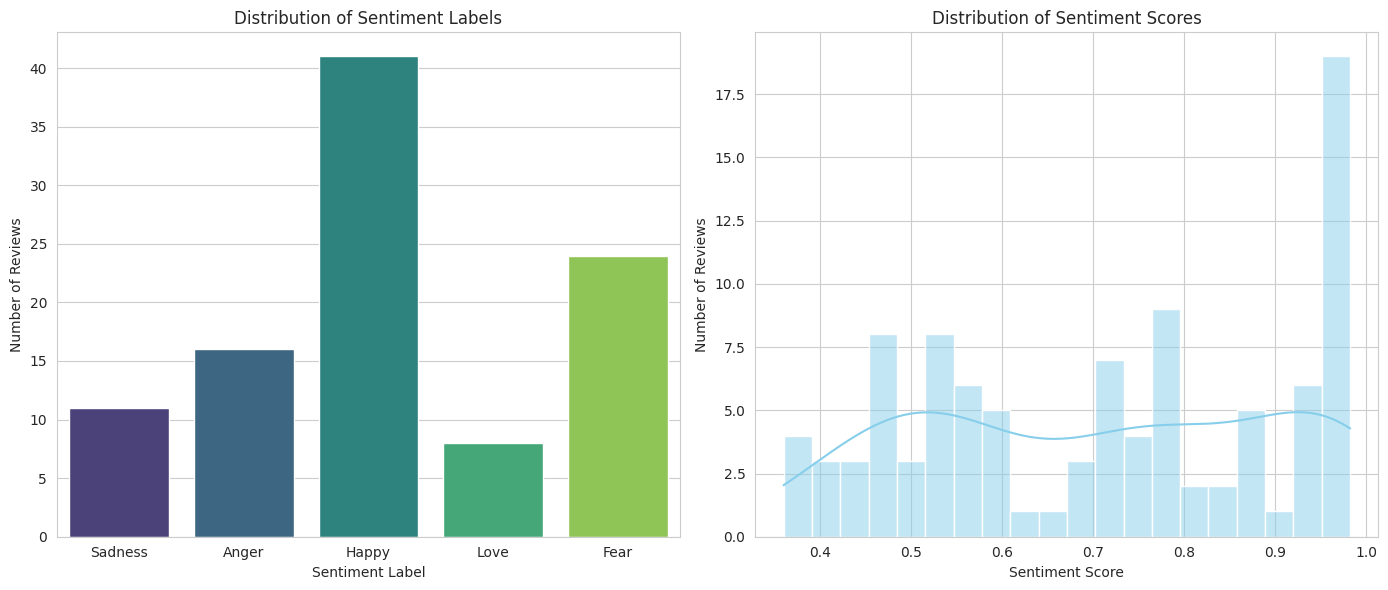

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of Sentiment Labels
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='sentiment_label', data=df_reviews, hue='sentiment_label', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Reviews')

# Subplot 2: Distribution of Sentiment Scores
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_reviews['sentiment_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Reviews')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()